# Signal Uncertainties

A walk-through of how the simplified-likelihood backends in Spey use signal-side systematic uncertainties through log-normal morphing, with numerical examples on a two-bin model.

## Introduction

Hypothesis tests in collider searches rest on the **profile likelihood ratio**
$\lambda(\mu) = \mathcal{L}(\mu, \hat{\hat{\boldsymbol{\theta}}})/\mathcal{L}(\hat\mu, \hat{\boldsymbol{\theta}})$,
where the nuisance parameters $\boldsymbol{\theta}$ are profiled out at every value
of the parameter of interest $\mu$. Background systematics — luminosity, jet energy
scale, MC statistics — are commonly absorbed into $\boldsymbol{\theta}$ via Gaussian
constraint terms. **Signal** systematics (theory-cross-section, PDF, QCD-scale, acceptance) play exactly the same role: they shift the predicted signal yield in
each bin and therefore broaden the $\chi^{2}(\mu)$ profile, which in turn relaxes
the upper limit on $\mu$.

Spey exposes signal uncertainties through the `modifiers` keyword of the
`default.*` backends. Each modifier introduces additional nuisance parameters
with standard-normal priors and a multiplicative log-normal morphing of the
nominal signal yield. This notebook derives the modified likelihood for every
supported modifier type and demonstrates the numerical impact on a two-bin
toy.

## Likelihood structure without signal uncertainties

For the uncorrelated-background backend (`default.uncorrelated_background`) the
likelihood factorises over $N$ statistically independent bins,

$$
\mathcal{L}(\mu, \boldsymbol{\theta})
= \prod_{i=1}^{N}
  \mathrm{Poiss}\bigl(n^{\mathrm{obs}}_i \,\bigm|\, \lambda_i(\mu, \theta_i)\bigr)
  \;\cdot\;
  \prod_{i=1}^{N} \mathcal{N}(\theta_i \mid 0, 1),
$$

with the expected count in bin $i$

$$
\lambda_i(\mu, \theta_i) \;=\; \mu\, n^{(s)}_i + n^{(b)}_i + \sigma_i\,\theta_i.
$$

Symbol dictionary:

| Symbol | Meaning |
| :-- | :-- |
| $\mu$ | signal-strength parameter of interest (POI) |
| $n^{(s)}_i$ | nominal signal yield in bin $i$ |
| $n^{(b)}_i$ | nominal background yield in bin $i$ |
| $\sigma_i$ | absolute background uncertainty in bin $i$ |
| $\theta_i$ | background nuisance parameter for bin $i$ (standard-normal prior) |
| $n^{\mathrm{obs}}_i$ | observed event count in bin $i$ |

The **test statistic** for upper limits is

$$
q_\mu \;=\;
\begin{cases}
-2\ln\dfrac{\mathcal{L}(\mu,\,\hat{\hat{\boldsymbol{\theta}}}(\mu))}
                {\mathcal{L}(\hat\mu,\,\hat{\boldsymbol{\theta}})},
& \hat\mu \le \mu, \\[6pt]
0, & \hat\mu > \mu,
\end{cases}
$$

where $\hat\mu, \hat{\boldsymbol{\theta}}$ are the global maximum-likelihood
estimators and $\hat{\hat{\boldsymbol{\theta}}}(\mu)$ are the *conditional*
MLEs at fixed $\mu$. Throughout this notebook we plot the symmetric profile
$\Delta\chi^{2}(\mu) = -2\bigl[\ln\mathcal{L}(\mu,\hat{\hat{\boldsymbol{\theta}}}(\mu)) - \ln\mathcal{L}(\hat\mu,\hat{\boldsymbol{\theta}})\bigr]$,
which under Wilks' theorem is asymptotically $\chi^{2}_{1}$-distributed and crosses
$3.84$ at the two-sided $95\,\%$ confidence level.

## How signal uncertainties modify the likelihood

Spey implements signal systematics via **log-normal morphing** of the nominal
signal yield. For an uncertainty source $k$ with per-bin absolute variation
$\sigma^{(s)}_{i,k}$, define the per-bin fractional shift

$$
\Delta_{i,k} \;=\; \frac{\sigma^{(s)}_{i,k}}{n^{(s)}_i}.
$$

The synthesizer in `spey.backends.default_pdf.uncertainty_synthesizer` exposes
two modifier types, selected via the `"type"` key of each modifier dictionary.
Each modifier also accepts a `"name"` (used for parameter labelling) and
`"uncertainties"` (per-bin absolute values; a flat `list[float]` for symmetric
uncertainties or a `list[(up, down)]` for asymmetric ones).

### `"type": "normalization"` — one shared nuisance

A single nuisance parameter $\theta_k$ is shared across all bins. The morphing
factor in bin $i$ is

$$
f_{i,k}(\theta_k) \;=\; \exp\!\bigl[\theta_k \,\ln(1 + \Delta_{i,k}(\theta_k))\bigr],
\qquad
\Delta_{i,k}(\theta_k) = \begin{cases} \Delta^{+}_{i,k}, & \theta_k \ge 0, \\ \Delta^{-}_{i,k}, & \theta_k < 0. \end{cases}
$$

The full likelihood for the uncorrelated-background backend becomes

$$
\mathcal{L}(\mu, \boldsymbol{\theta}, \theta_k)
= \prod_{i=1}^{N}
    \mathrm{Poiss}\!\Bigl(n^{\mathrm{obs}}_i \,\Big|\,
       \mu\, n^{(s)}_i\, f_{i,k}(\theta_k) + n^{(b)}_i + \sigma_i \theta_i\Bigr)
\cdot \prod_{i=1}^{N} \mathcal{N}(\theta_i \mid 0, 1)
\cdot \mathcal{N}(\theta_k \mid 0, 1).
$$

Use this for sources that move all bins coherently — luminosity,
cross-section normalisation, or a global PDF-eigenvector variation.

### `"type": "shape"` — one nuisance per bin

Each bin receives its own independent nuisance $\alpha_{i,k}$, with morphing
factor

$$
f_{i,k}(\alpha_{i,k}) \;=\; \exp\!\bigl[\alpha_{i,k} \,\ln(1 + \Delta_{i,k}(\alpha_{i,k}))\bigr].
$$

The likelihood gains $N$ independent standard-normal constraint factors:

$$
\mathcal{L}(\mu, \boldsymbol{\theta}, \boldsymbol{\alpha}_k)
= \prod_{i=1}^{N}
    \mathrm{Poiss}\!\Bigl(n^{\mathrm{obs}}_i \,\Big|\,
      \mu\, n^{(s)}_i\, f_{i,k}(\alpha_{i,k}) + n^{(b)}_i + \sigma_i \theta_i\Bigr)
\cdot \prod_{i=1}^{N} \mathcal{N}(\theta_i \mid 0, 1)
\cdot \prod_{i=1}^{N} \mathcal{N}(\alpha_{i,k} \mid 0, 1).
$$

This is the right choice when an uncertainty distorts the *shape* of the
distribution — bin-by-bin scale-variation envelopes, MC-statistical errors on
theory templates, or any source whose bins are not coherently correlated.

### Multiple sources combine multiplicatively

When several modifiers are stacked the per-bin signal modifier is the product
of the individual factors:

$$
f_i(\boldsymbol{\theta}_{\mathrm{sig}}) \;=\; \prod_k f_{i,k}
\;=\; \exp\!\Bigl[\sum_k \theta_k \,\ln(1+\Delta_{i,k}(\theta_k))\Bigr],
$$

and the constraint term is a product of independent standard-normal priors —
one per shared `normalization` nuisance, $N$ per `shape` modifier. The Poisson
term **does not** factorise over modifiers because they all multiply the same
$\mu\, n^{(s)}_i$, but the constraint term does.

Bins with $n^{(s)}_i = 0$ produce $\Delta_{i,k} = \mathrm{NaN}$; the
synthesizer replaces those with $1$ so the morphing factor is identically $1$ in
those bins.

## Which backends accept signal uncertainties

The four `default.*` simplified-likelihood backends all accept the
`modifiers` keyword and route it through the same
`signal_uncertainty_synthesizer`. The cell below introspects every backend
registered with `spey.AvailableBackends()` and reports whether the
constructor signature exposes a `modifiers` parameter.

In [1]:
import os
os.environ.setdefault("SPEY_LOGLEVEL", "0")

import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import spey

In [2]:
def _supports_modifiers(name: str) -> bool:
    """Return True if the backend's constructor exposes a ``modifiers`` kwarg."""
    try:
        wrapper = spey.get_backend(name)
    except Exception:
        return False
    return "modifiers" in inspect.signature(wrapper).parameters


_compat = pd.DataFrame(
    [
        {"backend": name, "accepts_modifiers": _supports_modifiers(name)}
        for name in sorted(spey.AvailableBackends())
    ]
)
_compat

,backend,accepts_modifiers
0,default.correlated_background,True
1,default.effective_sigma,True
2,default.multivariate_normal,False
3,default.normal,False
4,default.poisson,False
5,default.third_moment_expansion,True
6,default.uncorrelated_background,True
7,hs3,False
8,pyhf,False
9,pyhf.simplify,False


All four `default.*` simplified-likelihood backends — `uncorrelated_background`,
`correlated_background`, `third_moment_expansion`, and `effective_sigma` —
share the same `modifiers` plumbing. Backends that wrap an external
model-building framework (e.g. the `pyhf.*` family) carry their own
systematics machinery and do not expose this keyword.

## Baseline model

We work with a two-bin counting experiment in which both bins exhibit a
downward fluctuation relative to the background-plus-nominal-signal
prediction. This is the same model used throughout the [signal-uncertainty
discussion in the Spey docs](signal_unc.md) and is small enough that the
log-normal morphing is easy to follow numerically.

In [3]:
pdf_wrapper = spey.get_backend("default.uncorrelated_background")

baseline_model = pdf_wrapper(
    signal_yields=[12.0, 15.0],
    background_yields=[50.0, 48.0],
    data=[36, 33],
    absolute_uncertainties=[12.0, 16.0],
)

print(f"backend            : {baseline_model.backend_type}")
print(f"chi2(mu = 1)       : {baseline_model.chi2(poi_test=1.0):.4f}")
print(f"95% CL mu upper    : {baseline_model.poi_upper_limit():.4f}")

backend            : default.uncorrelated_background
chi2(mu = 1)       : 4.9138
95% CL mu upper    : 0.8563


## Adding signal uncertainties

The next three subsections build a variant of the baseline model with each
modifier type in turn, then a combined variant that stacks both. All variants
share the same observed data and background model, only the signal-side
constraint structure changes.

### Normalization modifier: PDF-style coherent variation

PDF-eigenvector variations (PDF4LHC prescription) move the inclusive
cross-section coherently across the kinematic spectrum. A single nuisance
parameter therefore captures the bulk of the effect. Here we apply a $15\,\%$
relative PDF uncertainty to each bin, which corresponds to $1.8$ and $2.25$
events in absolute terms ($0.15 \times 12$ and $0.15 \times 15$).

In [4]:
# 15% relative PDF uncertainty per bin -> absolute values of 0.15 * n_s_i.
norm_model = pdf_wrapper(
    signal_yields=[12.0, 15.0],
    background_yields=[50.0, 48.0],
    data=[36, 33],
    absolute_uncertainties=[12.0, 16.0],
    modifiers=[
        {"type": "normalization", "name": "pdf", "uncertainties": [1.8, 2.25]},
    ],
)

print(f"baseline chi2(mu=1) : {baseline_model.chi2(poi_test=1.0):.4f}")
print(f"normalization chi2  : {norm_model.chi2(poi_test=1.0):.4f}")

baseline chi2(mu=1) : 4.9138
normalization chi2  : 4.7284


### Shape modifier: bin-by-bin scale variation

QCD scale variations ($\mu_R, \mu_F$ rescaled by conventional factors of two)
behave differently from PDFs: the envelope is bin-dependent because
higher-order corrections grow with the event hardness. A `shape` modifier with
asymmetric `(up, down)` values mirrors the asymmetric envelopes typically
tabulated by NLO generators. Here we use $\pm 20\,\%$ in bin 0 and
$\pm 25\,\%$ in bin 1 with a $\sim 5\,\%$ up/down asymmetry to imitate
a real scale envelope.

In [5]:
# Asymmetric (up, down) absolute uncertainties per bin.
# Bin 0: +20% / -15% on n_s = 12  ->  (+2.4, -1.8)
# Bin 1: +25% / -20% on n_s = 15  ->  (+3.75, -3.0)
shape_model = pdf_wrapper(
    signal_yields=[12.0, 15.0],
    background_yields=[50.0, 48.0],
    data=[36, 33],
    absolute_uncertainties=[12.0, 16.0],
    modifiers=[
        {
            "type": "shape",
            "name": "scale",
            "uncertainties": [(2.4, 1.8), (3.75, 3.0)],
        },
    ],
)

print(f"baseline chi2(mu=1) : {baseline_model.chi2(poi_test=1.0):.4f}")
print(f"shape    chi2(mu=1) : {shape_model.chi2(poi_test=1.0):.4f}")

baseline chi2(mu=1) : 4.9138
shape    chi2(mu=1) : 4.7881


### Combined modifiers: PDF and scale together

A realistic theory uncertainty stacks both: a coherent PDF variation plus a
bin-dependent scale envelope. As shown in Section 3.3, the morphing factors
multiply bin-by-bin while their constraint terms remain independent.

In [7]:
combined_model = pdf_wrapper(
    signal_yields=[12.0, 15.0],
    background_yields=[50.0, 48.0],
    data=[36, 33],
    absolute_uncertainties=[12.0, 16.0],
    modifiers=[
        {"type": "normalization", "name": "pdf", "uncertainties": [1.8, 2.25]},
        {
            "type": "shape",
            "name": "scale",
            "uncertainties": [(2.4, 1.8), (3.75, 3.0)],
        },
    ],
)

print(f"baseline chi2(mu=1) : {baseline_model.chi2(poi_test=1.0):.4f}")
print(f"combined chi2(mu=1) : {combined_model.chi2(poi_test=1.0):.4f}")

baseline chi2(mu=1) : 4.9138
combined chi2(mu=1) : 4.6213


## Visualising the effect on the $\chi^{2}$ profile

We scan $\mu \in [0, 3]$ at $80$ points for every model and plot the profile
$-2\,\Delta\ln\mathcal{L}(\mu) = q_\mu$. The Wilks threshold at $3.84$ marks
the two-sided $95\,\%$ CL crossing; the loosest model is the one whose curve
crosses the threshold furthest to the right.

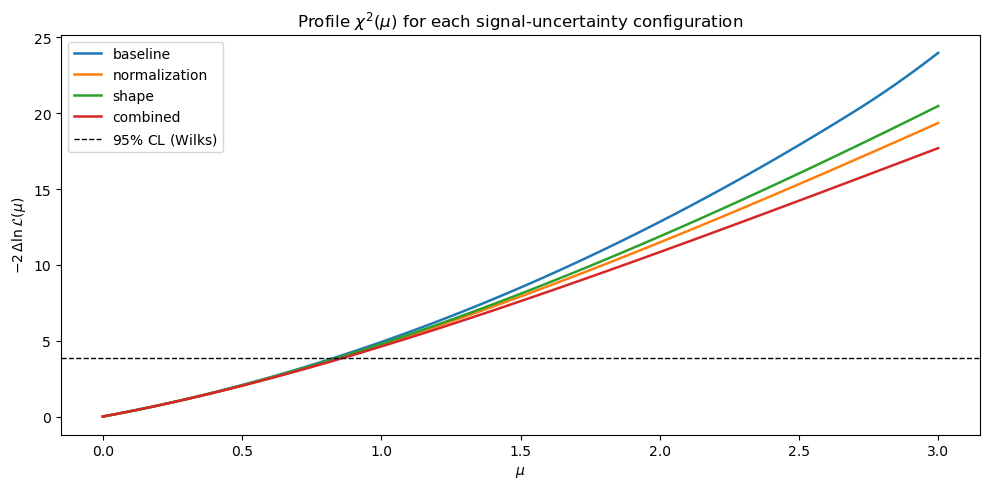

In [8]:
models = {
    "baseline":      baseline_model,
    "normalization": norm_model,
    "shape":         shape_model,
    "combined":      combined_model,
}

mu_scan = np.linspace(0.0, 3.0, 80)
chi2_curves = {
    label: np.array([m.chi2(poi_test=mu) for mu in mu_scan])
    for label, m in models.items()
}

fig, ax = plt.subplots(figsize=(10, 5))
for label, curve in chi2_curves.items():
    ax.plot(mu_scan, curve, label=label, linewidth=1.8)
ax.axhline(3.84, color="black", linestyle="--", linewidth=1.0,
           label=r"$95\%$ CL (Wilks)")
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$-2\,\Delta\ln\mathcal{L}(\mu)$")
ax.set_title(r"Profile $\chi^{2}(\mu)$ for each signal-uncertainty configuration")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Effect on exclusion limits

The $95\,\%$ CL upper limit on $\mu$ is obtained from
`statistical_model.poi_upper_limit()`. We tabulate the limit for the baseline
model and every variant together with the relative shift in percent.

In [9]:
baseline_limit = baseline_model.poi_upper_limit()

rows = []
for label, m in models.items():
    limit = m.poi_upper_limit()
    rows.append(
        {
            "model": label,
            "upper_limit_mu": limit,
            "delta_vs_baseline_pct": 100.0 * (limit - baseline_limit) / baseline_limit,
        }
    )

limit_table = pd.DataFrame(rows)
limit_table

,model,upper_limit_mu,delta_vs_baseline_pct
0,baseline,0.856335,0.000000
1,normalization,0.877000,2.413259
2,shape,0.870038,1.600235
3,combined,0.890584,3.999557


The **combined** variant has the largest upper limit on $\mu$ — both morphing
factors enlarge the allowed signal envelope and the profile likelihood
compensates by accepting a larger $\mu$ before the data become inconsistent.
Among the single-source variants the **normalization** modifier produces the
larger shift even though its per-bin variation ($15\,\%$) is *smaller* than the
`shape` modifier ($20$–$25\,\%$): a single shared nuisance can pull the signal
down coherently in both bins at a Gaussian penalty of only $\theta^{2}/2$,
whereas the two independent `shape` nuisances each pay their own
$\alpha_{i}^{2}/2$ penalty to achieve the same coherent shift, making the
shape handle stiffer despite its larger nominal envelope.

## Summary

* Signal systematics are absorbed by **log-normal morphing** of the nominal
  signal yield ($f_{i,k}(\theta_k) = \exp[\theta_k\ln(1+\Delta_{i,k})]$),
  introducing additional nuisance parameters with standard-normal priors.
* Pick `"type": "normalization"` for sources that move all bins
  coherently, luminosity, cross-section normalisation, single-eigenvector PDF
  variations. One nuisance parameter is added.
* Pick `"type": "shape"` for sources whose bin-by-bin effect is
  uncorrelated, scale envelopes, MC-stat errors on theory templates. One
  nuisance parameter per bin is added.
* Multiple modifiers stack multiplicatively in the Poisson term and additively
  in the log-constraint term; they always inflate the $\chi^{2}$
  profile and therefore relax the upper limit.
* All four `default.*` simplified-likelihood backends; `uncorrelated_background`,
  `correlated_background`, `third_moment_expansion`, and `effective_sigma`,
  accept the same `modifiers` keyword.